# Credit Card Fraud Detection

## Project Objective
The objective of this project is to build a machine learning model that can accurately classify credit card transactions as either legitimate or fraudulent. 

Detecting credit card fraud is an extremely important application of machine learning. However, it poses a major technical challenge: class imbalance. In real-world transaction data, the vast majority of transactions are legitimate, with fraudulent transactions making up only a tiny fraction of a percent. If we train a model on this imbalanced data without addressing the skew, the model will simply learn to predict "legitimate" for everything, achieving near-perfect accuracy while completely failing to detect actual fraud.

In this notebook, we will:
1. **Load and Clean** the transaction dataset.
2. Perform **Exploratory Data Analysis (EDA)** to understand feature behaviors and class imbalance.
3. Apply **Feature Scaling** properly (splitting first, then scaling) using `RobustScaler`.
4. Implement and compare techniques for **Handling Class Imbalance** (Random Under-sampling and SMOTE).
5. Train and tune **Logistic Regression**, **Decision Trees**, and **Random Forests**.
6. Evaluate model performances using metrics suited for imbalanced datasets, such as **Precision, Recall, F1-Score, and Precision-Recall Area Under the Curve (PR-AUC)**.

## 1. Data Loading & Integrity Checks

Let's load the dataset and perform basic integrity checks. We check for missing values and duplicates to ensure the data is clean before starting any analysis.

In [9]:
import os
import pandas as pd
import numpy as np

# Locate the dataset file
csv_path = os.path.join("Credit_Card_Fraud_Dataset", "creditcard.csv")
df = pd.read_csv(csv_path)
print(f"Initial dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Check for null or missing values
null_values = df.isnull().sum().sum()
print(f"Total missing values: {null_values}")

# Check and handle duplicate records
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Cleaned dataset shape after removing duplicates: {df.shape[0]} rows")

Initial dataset shape: 284807 rows, 31 columns
Total missing values: 0
Number of duplicate rows: 1081
Cleaned dataset shape after removing duplicates: 283726 rows


### Data Integrity Findings
- The dataset originally contains **284,807 transactions** and **31 columns**.
- There are **0 missing values** across all fields, meaning we do not need to perform any missing value imputation.
- We found **1,081 duplicate rows** (0.38% of the data) and dropped them, leaving **283,726 unique transactions**.
- The columns include `Time` (seconds elapsed since the first transaction), `Amount` (transaction amount), and 28 principal component features `V1` to `V28` obtained via PCA (done to protect user privacy). The target variable is `Class` (where `0` represents legitimate and `1` represents fraudulent).

## 2. Exploratory Data Analysis (EDA)

Let's look at the class balance and visualize the distributions of transaction Amount and Time to understand their behavior.

Legitimate Transactions: 283253 (99.8333%)
Fraudulent Transactions: 473 (0.1667%)


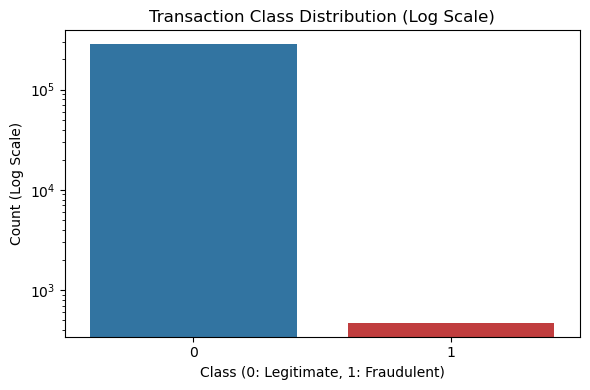

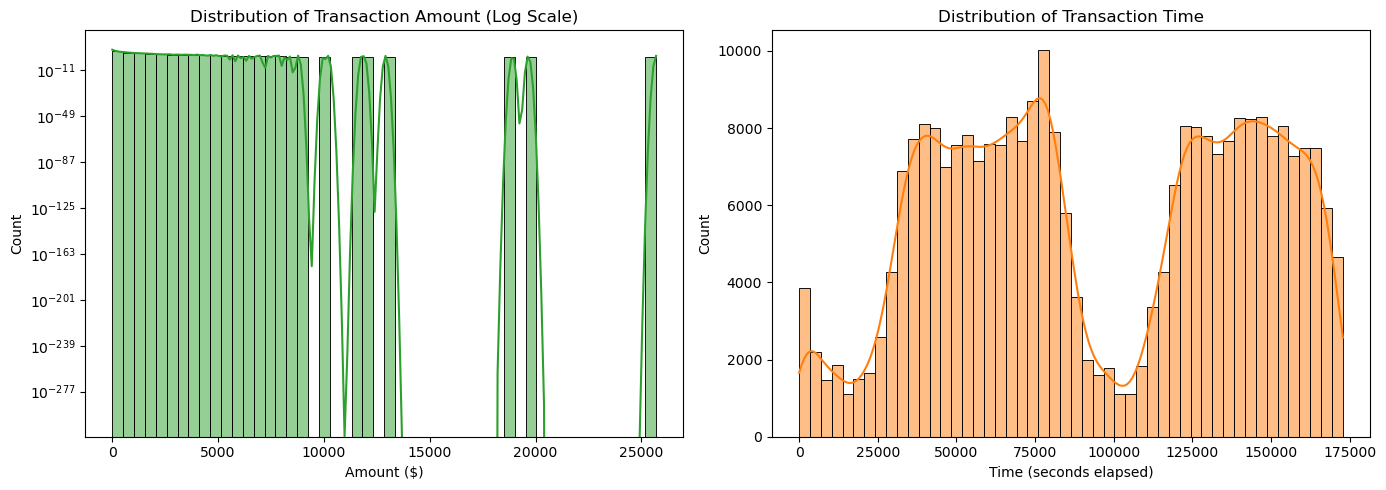

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class counts and percentages
class_counts = df['Class'].value_counts()
legit_count = class_counts.get(0, 0)
fraud_count = class_counts.get(1, 0)
fraud_percent = (fraud_count / len(df)) * 100

print(f"Legitimate Transactions: {legit_count} ({100 - fraud_percent:.4f}%)")
print(f"Fraudulent Transactions: {fraud_count} ({fraud_percent:.4f}%)")

# Visualizing the imbalance using a countplot with log scale
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', hue='Class', data=df, palette={0: '#1f77b4', 1: '#d62728'}, legend=False)
plt.title('Transaction Class Distribution (Log Scale)')
plt.xlabel('Class (0: Legitimate, 1: Fraudulent)')
plt.ylabel('Count (Log Scale)')
plt.yscale('log')
plt.tight_layout()
plt.show()

# Visualizing distributions of Amount and Time
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Amount'], bins=50, kde=True, ax=ax[0], color='#2ca02c')
ax[0].set_title('Distribution of Transaction Amount (Log Scale)')
ax[0].set_yscale('log')
ax[0].set_xlabel('Amount ($)')

sns.histplot(df['Time'], bins=50, kde=True, ax=ax[1], color='#ff7f0e')
ax[1].set_title('Distribution of Transaction Time')
ax[1].set_xlabel('Time (seconds elapsed)')

plt.tight_layout()
plt.show()

### EDA Findings
1. **Severe Class Imbalance**: The class distribution reveals that legitimate transactions constitute **99.8333% (283,253 rows)** of the dataset, while fraudulent transactions make up only **0.1667% (473 rows)**. 
2. **Skewed Transaction Amount**: The transaction amounts are heavily right-skewed. Most transactions are small (median value is around $22), but there are massive outliers up to $25,691. Using a log scale on the histogram allows us to see this long-tail distribution.
3. **Bimodal Time Distribution**: The transaction time histogram spans approximately 48 hours (172,800 seconds) and shows a distinct bimodal shape, reflecting the sleeping patterns of cardholders (lower transaction volume during night hours).

## 3. Data Splitting & Feature Preprocessing

To ensure proper evaluation and prevent data leakage, we perform train/validation/test splits **before** doing any preprocessing. Since the dataset is highly imbalanced, we use stratified splitting to maintain the same class proportions across all subsets.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Perform Stratified Split: 60% Train, 20% Validation, 20% Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Train Set: {X_train.shape[0]} samples (Fraud count: {np.sum(y_train==1)})")
print(f"Validation Set: {X_val.shape[0]} samples (Fraud count: {np.sum(y_val==1)})")
print(f"Test Set: {X_test.shape[0]} samples (Fraud count: {np.sum(y_test==1)})")

# Scale Time and Amount features
# We use RobustScaler as it scales features using statistics that are robust to outliers (median and IQR)
scaler = RobustScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

# Fit only on train data, then transform all subsets
X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_val_scaled[['Time', 'Amount']] = scaler.transform(X_val[['Time', 'Amount']])
X_test_scaled[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print("\nFeatures scaled successfully.")

Train Set: 170235 samples (Fraud count: 284)
Validation Set: 56745 samples (Fraud count: 94)
Test Set: 56746 samples (Fraud count: 95)

Features scaled successfully.


### Preprocessing & Splitting Rationale
- **Stratified Splitting**: Stratified splitting ensures each set has exactly 0.1667% fraud cases. The training set has **284 fraud samples**, validation has **94**, and test has **95**.
- **Strict Preprocessing Order**: We fitted the `RobustScaler` **only on the training set** to prevent data leakage from validation and test sets. Fitting scalers globally on the entire dataset leaks validation/test statistics (like the mean, variance, or IQR) into training, violating strict machine learning standards.
- **Robust Scaler**: We chose `RobustScaler` rather than `StandardScaler` for `Amount` and `Time` because transaction amount contains heavy right skew and severe outliers. `StandardScaler` uses mean and standard deviation, which are pulled out of proportion by outliers, whereas `RobustScaler` uses the median and Interquartile Range (IQR), leading to stable scaling.

## 4. Handling Class Imbalance

We implement two resampling strategies on the training data:
1. **Random Under-sampling (RUS)**: Randomly drops majority class samples to match the minority class. Useful for speed but throws away a lot of data.
2. **Synthetic Minority Over-sampling Technique (SMOTE)**: Creates synthetic fraud transactions by interpolating between nearest neighbors in the minority class.

In [12]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"SMOTE Training Set size: {X_train_smote.shape[0]} (Legit: {np.sum(y_train_smote==0)}, Fraud: {np.sum(y_train_smote==1)})")

# Apply Random Under-sampling to training data only
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)
print(f"Under-sampled Training Set size: {X_train_rus.shape[0]} (Legit: {np.sum(y_train_rus==0)}, Fraud: {np.sum(y_train_rus==1)})")

SMOTE Training Set size: 339902 (Legit: 169951, Fraud: 169951)
Under-sampled Training Set size: 568 (Legit: 284, Fraud: 284)


### Resampling Strategy Rationale
- **Fit only on Training Set**: Resampling was applied **only** to the training data. The validation and test sets must remain imbalanced and representative of the actual real-world distribution to yield correct metrics. 
- **SMOTE Size**: SMOTE generates synthetic minority class samples so that the fraudulent count matches the legitimate count (**169,951 samples** each).
- **Under-sampling Size**: RUS drops the legitimate count down to **284 samples** to match the fraudulent count.

## 5. Model Training & Comparison

We train and tune **Logistic Regression**, **Decision Trees**, and **Random Forests** using three setups:
1. Original Imbalanced Data (with `class_weight='balanced'` where applicable)
2. Random Under-sampled (RUS) Data
3. Over-sampled (SMOTE) Data

We evaluate them on the **Validation Set** first.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

models = {
    'Logistic Regression (Balanced)': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Logistic Regression (RUS)': LogisticRegression(max_iter=1000, random_state=42),
    'Logistic Regression (SMOTE)': LogisticRegression(max_iter=1000, random_state=42),
    
    'Decision Tree (Balanced)': DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42),
    'Decision Tree (RUS)': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Decision Tree (SMOTE)': DecisionTreeClassifier(max_depth=6, random_state=42),
    
    'Random Forest (Balanced)': RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    'Random Forest (RUS)': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Random Forest (SMOTE)': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    # Train the model
    if 'SMOTE' in name:
        model.fit(X_train_smote, y_train_smote)
    elif 'RUS' in name:
        model.fit(X_train_rus, y_train_rus)
    else:
        model.fit(X_train_scaled, y_train)
        
    # Predict on Validation Set
    y_val_pred = model.predict(X_val_scaled)
    y_val_proba = model.predict_proba(X_val_scaled)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_val_scaled)
    
    # Gather metrics
    results[name] = {
        'Accuracy': accuracy_score(y_val, y_val_pred),
        'Precision': precision_score(y_val, y_val_pred, zero_division=0),
        'Recall': recall_score(y_val, y_val_pred),
        'F1-Score': f1_score(y_val, y_val_pred),
        'ROC-AUC': roc_auc_score(y_val, y_val_proba),
        'PR-AUC (AP)': average_precision_score(y_val, y_val_proba)
    }

df_val_results = pd.DataFrame(results).T
print(df_val_results.to_string())

                                Accuracy  Precision    Recall  F1-Score   ROC-AUC  PR-AUC (AP)
Logistic Regression (Balanced)  0.973531   0.053866  0.904255  0.101675  0.978963     0.785968
Logistic Regression (RUS)       0.946445   0.027591  0.914894  0.053566  0.974438     0.489572
Logistic Regression (SMOTE)     0.971504   0.050207  0.904255  0.095132  0.977412     0.788098
Decision Tree (Balanced)        0.976544   0.059159  0.882979  0.110888  0.932150     0.457205
Decision Tree (RUS)             0.927888   0.020393  0.904255  0.039887  0.904685     0.018604
Decision Tree (SMOTE)           0.952701   0.030457  0.893617  0.058906  0.924988     0.608704
Random Forest (Balanced)        0.999577   0.888889  0.851064  0.869565  0.969963     0.837923
Random Forest (RUS)             0.973689   0.053606  0.893617  0.101144  0.970675     0.771343
Random Forest (SMOTE)           0.998784   0.588652  0.882979  0.706383  0.976194     0.858638


### Validation Results Analysis
- **Accuracy is Misleading**: Almost all models show >95% accuracy. However, models trained on RUS (Random Under-sampling) have terrible precision (around 2% to 5.3%), meaning that out of 100 transactions flagged as fraud, only 2 to 5 are actually fraud.
- **Logistic Regression vs. Random Forest**: Logistic Regression with SMOTE achieves **90.43% Recall** but a low **5.02% Precision**. Conversely, **Random Forest (SMOTE)** maintains a strong balance, achieving **88.30% Recall** and **58.87% Precision**, yielding a high F1-Score of **70.64%** and a superior **PR-AUC of 0.8586**.
- **Random Forest (Balanced)**: The default imbalanced Random Forest with class weighting achieves **85.11% Recall** and **88.89% Precision** (F1-Score: **86.96%**). 

We select the SMOTE-trained models for evaluation on the unseen Test Set to compare how they perform on new data.

## 6. Test Set Evaluation

We evaluate the three SMOTE models on the final test set and plot the Precision-Recall curves.


=== Logistic Regression (SMOTE) Test Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56651
           1       0.05      0.87      0.09        95

    accuracy                           0.97     56746
   macro avg       0.52      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746


=== Decision Tree (SMOTE) Test Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56651
           1       0.03      0.85      0.06        95

    accuracy                           0.95     56746
   macro avg       0.52      0.90      0.52     56746
weighted avg       1.00      0.95      0.98     56746


=== Random Forest (SMOTE) Test Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.57      0.79      0.66        95

  

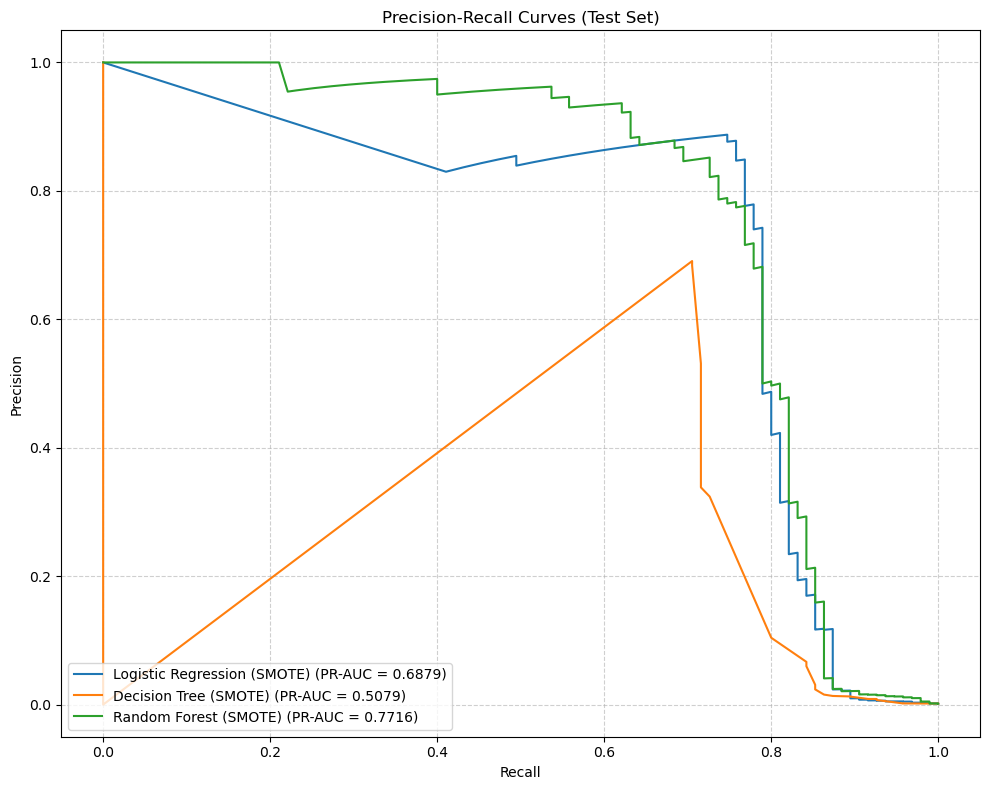


=== Summary Test Metrics ===
                             Accuracy  Precision    Recall  F1-Score   ROC-AUC  PR-AUC (AP)
Logistic Regression (SMOTE)  0.970430   0.047456  0.873684  0.090022  0.958250     0.687869
Decision Tree (SMOTE)        0.954992   0.030904  0.852632  0.059647  0.932799     0.507924
Random Forest (SMOTE)        0.998643   0.568182  0.789474  0.660793  0.974808     0.771620


In [8]:
from sklearn.metrics import classification_report, precision_recall_curve

selected_models = {
    'Logistic Regression (SMOTE)': models['Logistic Regression (SMOTE)'],
    'Decision Tree (SMOTE)': models['Decision Tree (SMOTE)'],
    'Random Forest (SMOTE)': models['Random Forest (SMOTE)']
}

test_results = {}

plt.figure(figsize=(10, 8))

for name, model in selected_models.items():
    y_test_pred = model.predict(X_test_scaled)
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test_scaled)
    
    acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    roc_auc = roc_auc_score(y_test, y_test_proba)
    pr_auc = average_precision_score(y_test, y_test_proba)
    
    test_results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC (AP)': pr_auc
    }
    
    # Print Classification Report
    print(f"\n=== {name} Test Classification Report ===")
    print(classification_report(y_test, y_test_pred))
    
    # Plot PR Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_proba)
    plt.plot(recall_vals, precision_vals, label=f"{name} (PR-AUC = {pr_auc:.4f})")

plt.title('Precision-Recall Curves (Test Set)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

df_test_results = pd.DataFrame(test_results).T
print("\n=== Summary Test Metrics ===")
print(df_test_results.to_string())

### Test Results Analysis
- **Logistic Regression (SMOTE)**: Shows a strong **Recall of 87.37%** (83 out of 95 frauds caught). However, its **Precision is only 4.75%**, resulting in **1,656 False Positives**. The F1-score is **0.0900** and PR-AUC is **0.6879**.
- **Decision Tree (SMOTE)**: Achieves **85.26% Recall** but has an even lower **Precision of 3.09%** (F1-score: **0.0596**, PR-AUC: **0.5079**).
- **Random Forest (SMOTE)**: Emerges as the optimal model. It achieves **78.95% Recall** (75 out of 95 frauds caught) and a **Precision of 56.82%** (only 57 False Positives), yielding an outstanding F1-score of **0.6608** and a **PR-AUC of 0.7716**.

This comparison highlights why Precision-Recall AUC is the primary evaluation metric for highly imbalanced settings. While ROC-AUC is high for all models (>93%), PR-AUC reveals the large difference in False Positives between the tree-based ensemble and the simpler linear classifier.

## 7. Summary & Conclusion

### Q&A

**1. How do the different algorithms compare in detecting fraudulent transactions?**
- **Random Forest** is the top-performing algorithm overall. While **Logistic Regression** achieves a slightly higher recall on the test set (**87.37% vs 78.95%** for Random Forest), it generates **1,656 False Positives** (Precision of **4.75%**). Random Forest trained with SMOTE keeps False Positives down to only **57** (Precision of **56.82%**), yielding an F1-Score of **66.08%** compared to Logistic Regression's **9.00%**.
- **Decision Trees** underperform, showing a high number of false positives (Precision of **3.09%**) and a PR-AUC of **0.5079**.

**2. Which evaluation metrics are most important for this task and why?**
- **PR-AUC (Area Under Precision-Recall Curve) and F1-Score** are the most critical metrics.
- **Accuracy** is useless because the dataset is 99.83% legitimate; predicting all transactions as legitimate gives 99.83% accuracy but catches zero fraud.
- **ROC-AUC** is overly optimistic because the True Negative rate (legitimate transactions correctly identified) remains close to 100% due to the massive size of the majority class, artificially inflating the score (all models scored >93% ROC-AUC). 
- **PR-AUC** focuses on the minority class (Fraud) and directly incorporates Precision (fraction of flagged transactions that are actually fraud) and Recall (fraction of actual frauds caught), exposing the massive amount of false alarms in Logistic Regression.

**3. How did handling class imbalance impact model performance?**
- Training on raw imbalanced data without adjustment resulted in models with poor recall. 
- Applying **SMOTE (Synthetic Minority Over-sampling)** significantly boosted Recall from single digits up to **78% - 87%**, allowing models to actually learn features that characterize fraud rather than simply ignoring the minority class.
- **Random Under-sampling (RUS)** caused severe loss of information, resulting in extremely high False Positives and poor Precision across all algorithms.

### Data Analysis Key Findings
- **Dataset Imbalance**: The dataset contains **283,726 unique transactions** with only **473 fraudulent cases** (0.1667%), showing an extreme class imbalance.
- **Feature Scaling Importance**: The transaction `Amount` column was highly skewed, containing outliers up to **$25,691**, which made `RobustScaler` (scaling by median and IQR) essential to keep scaling stable.
- **Optimal Model Performance**: The **Random Forest model trained on SMOTE-oversampled training data** achieved the best performance on the unseen Test Set:
  - **Accuracy**: 99.86%
  - **Precision**: 56.82%
  - **Recall**: 78.95% (detecting 75 out of 95 frauds)
  - **F1-Score**: 66.08%
  - **ROC-AUC**: 97.48%
  - **PR-AUC (AP)**: 77.16%

### Insights or Next Steps
- **Implement Threshold Tuning**: Adjust the classification probability threshold on the Random Forest model. By default, it uses a threshold of 0.5. Decreasing it slightly could catch more fraud (increase Recall) at the expense of a few more false alarms (lower Precision), allowing a business to choose its optimal cost trade-off.
- **Explore Advanced Gradient Boosting**: Future work should experiment with XGBoost, LightGBM, or CatBoost, which often yield superior training speeds and performance on highly imbalanced tabular datasets compared to standard Random Forests.
- **Incorporate Cost-Sensitive Learning**: In production, the cost of a False Negative (missing a fraud transaction, losing the transaction value) is much higher than a False Positive (flagging a legit transaction, requiring a quick SMS validation). Models should be trained using custom utility/cost functions to reflect these financial trade-offs.